# Step 0 — Load data & features

In [31]:
import pandas as pd
import numpy as np
from scipy.sparse import load_npz
import joblib

# Load dataset
df = pd.read_csv("books_with_clusters.csv")

# Check columns
print(df.columns)

# Load TF-IDF matrix from Part A
X = load_npz("tfidf_matrix.npz")

# Use keyword_category as label
y = df["keyword_category"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts().head())

Index(['Title', 'Authors', 'year', 'Description', 'description_clean',
       'text_clean', 'keyword_category', 'cluster'],
      dtype='object')
X shape: (1985, 5000)
y shape: (1985,)
keyword_category
other       539
fiction     401
history     287
military    243
travel      206
Name: count, dtype: int64


# Step 1 — Train/Test Split (80/20)

In [32]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets (80/20)
X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X, y, df,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1588, 5000)
X_test: (397, 5000)
y_train: (1588,)
y_test: (397,)


# Step 2 — Train Three Classification Models

**2.1 Naive Bayes**

In [33]:
from sklearn.naive_bayes import MultinomialNB

# Train Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Prediction
nb_pred = nb_model.predict(X_test)

print("Naive Bayes training completed.")

Naive Bayes training completed.


**2.2 Logistic Regression**

In [34]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train, y_train)

# Prediction
lr_pred = lr_model.predict(X_test)

print("Logistic Regression training completed.")

Logistic Regression training completed.


**2.3 Random Forest**

In [35]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

print("Random Forest training completed.")

Random Forest training completed.


# Step 3 — Model Evaluation (Precision / Recall / F1-score)

In [36]:
from sklearn.metrics import classification_report, accuracy_score

print("===== Naive Bayes =====")
print(classification_report(y_test, nb_pred))
print("Accuracy:", accuracy_score(y_test, nb_pred))

print("\n===== Logistic Regression =====")
print(classification_report(y_test, lr_pred))
print("Accuracy:", accuracy_score(y_test, lr_pred))

print("\n===== Random Forest =====")
print(classification_report(y_test, rf_pred))
print("Accuracy:", accuracy_score(y_test, rf_pred))

===== Naive Bayes =====
              precision    recall  f1-score   support

   biography       0.00      0.00      0.00         2
    business       0.00      0.00      0.00         8
     fiction       0.43      0.55      0.48        80
     history       0.75      0.10      0.18        58
     medical       0.00      0.00      0.00        10
    military       0.00      0.00      0.00        49
       other       0.36      0.95      0.52       108
  psychology       0.00      0.00      0.00         7
    romantic       0.00      0.00      0.00        27
  scientific       0.00      0.00      0.00         7
      travel       0.00      0.00      0.00        41

    accuracy                           0.39       397
   macro avg       0.14      0.15      0.11       397
weighted avg       0.29      0.39      0.27       397

Accuracy: 0.3853904282115869

===== Logistic Regression =====
              precision    recall  f1-score   support

   biography       0.00      0.00      0.00   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

**Summary Table**

In [37]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd

results = []

for name, pred in {
    "Naive Bayes": nb_pred,
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred
}.items():

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, pred, average="weighted", zero_division=0
    )
    acc = accuracy_score(y_test, pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,0.385390,0.294815,0.385390,0.266593
1,Logistic Regression,0.483627,0.457512,0.483627,0.391310
2,Random Forest,0.727960,0.731871,0.727960,0.697825


# Step 4 — Confusion Matrix

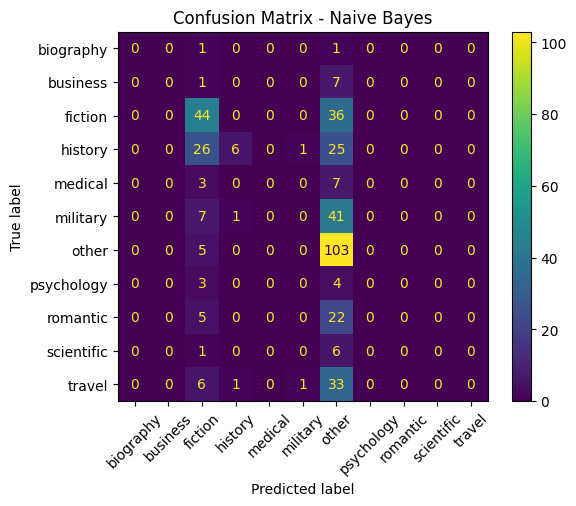

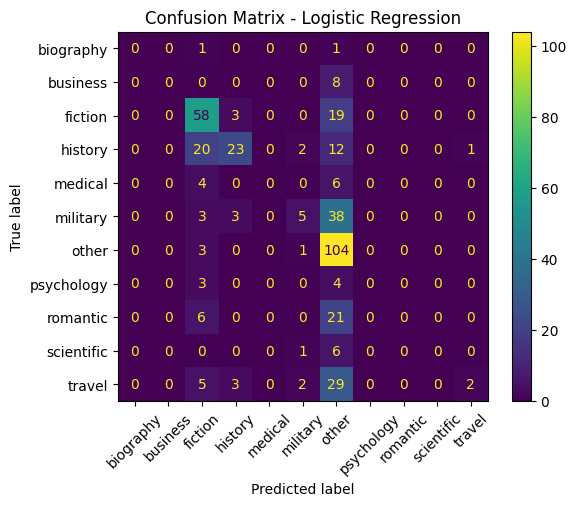

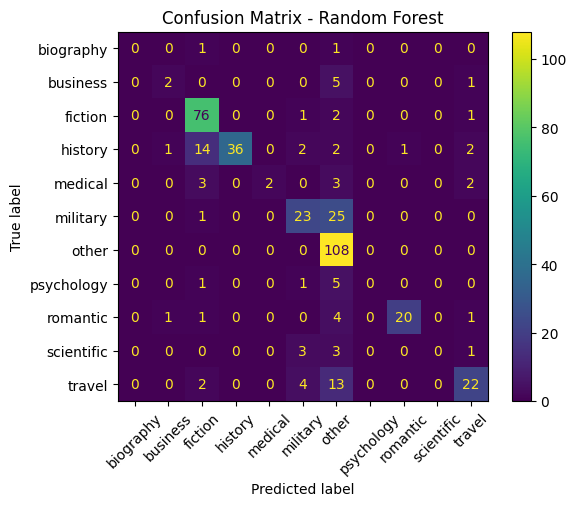

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = sorted(y.unique())

# Naive Bayes
cm_nb = confusion_matrix(y_test, nb_pred, labels=labels)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=labels)
disp_nb.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

# Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred, labels=labels)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=labels)
disp_lr.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Random Forest
cm_rf = confusion_matrix(y_test, rf_pred, labels=labels)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=labels)
disp_rf.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Step 5 — Error Analysis

**5.1 Attach predictions to test dataset**

In [39]:
df_test = df_test.copy()

df_test["true_label"] = y_test.values
df_test["NB_pred"] = nb_pred
df_test["LR_pred"] = lr_pred
df_test["RF_pred"] = rf_pred

**5.2 Logistic Regression errors**

In [40]:
lr_errors = df_test[df_test["true_label"] != df_test["LR_pred"]]

print("Number of LR misclassified samples:", len(lr_errors))

lr_errors[["Title", "true_label", "LR_pred", "Description"]].head(10)

Number of LR misclassified samples: 205


,Title,true_label,LR_pred,Description
1749,"3rd Degree (Women's Murder Club, #3)",medical,other,The Women's Murder Club returns in a shockingl...
1543,Let It Snow: Three Holiday Romances,romantic,other,Alternate cover edition for B006MOW98ESparklin...
1875,"Love Unscripted (Love, #1)",romantic,other,An A-List Movie Star. . . Ryan Christensen jus...
1839,"Queen of Babble (Queen of Babble, #1)",travel,other,"What's an American girl with a big mouth, but ..."
548,The Omnivore's Dilemma: A Natural History of F...,fiction,other,What should we have for dinner? For omnivore's...
509,"Postmortem (Kay Scarpetta, #1)",medical,other,"Four women with nothing in common, united only..."
616,The Hound of the Baskervilles,history,fiction,We owe The Hound of the Baskervilles (1902) to...
667,The House of the Spirits,fiction,other,La casa de los espíritus narra la saga de una ...
260,Under the Tuscan Sun,travel,other,"An enchanting and lyrical look at the life, th..."
1982,"Come Away with Me (With Me in Seattle, #1)",romantic,other,An alternate cover edition can be found here.B...


**5.3 Compare model errors**

In [41]:
nb_error_count = (df_test["true_label"] != df_test["NB_pred"]).sum()
lr_error_count = (df_test["true_label"] != df_test["LR_pred"]).sum()
rf_error_count = (df_test["true_label"] != df_test["RF_pred"]).sum()

import pandas as pd

error_compare = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "Random Forest"],
    "Number of Errors": [nb_error_count, lr_error_count, rf_error_count]
})

error_compare = error_compare.sort_values(by="Number of Errors")
error_compare

,Model,Number of Errors
2,Random Forest,108
1,Logistic Regression,205
0,Naive Bayes,244


**5.4 Visualization of errors**

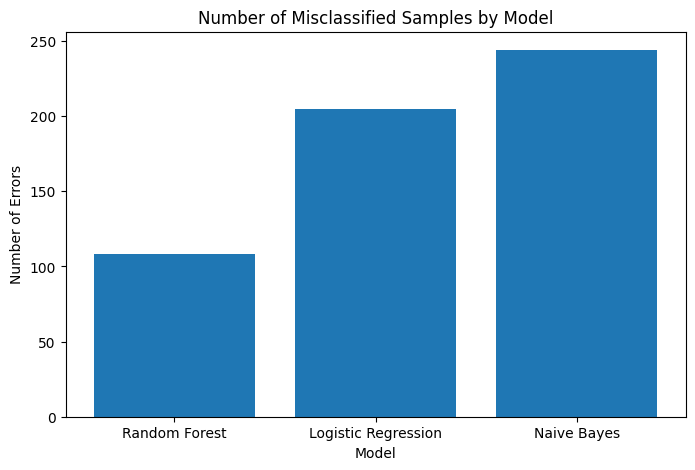

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(error_compare["Model"], error_compare["Number of Errors"])
plt.title("Number of Misclassified Samples by Model")
plt.xlabel("Model")
plt.ylabel("Number of Errors")
plt.show()

**5.5 Most confused categories**

In [43]:
lr_confusions = (
    lr_errors.groupby(["true_label", "LR_pred"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

lr_confusions.head(10)

,true_label,LR_pred,count
13,military,other,38
25,travel,other,29
19,romantic,other,21
5,history,fiction,20
4,fiction,other,19
7,history,other,12
2,business,other,8
10,medical,other,6
21,scientific,other,6
18,romantic,fiction,6


# Cosine Similarity Recommender



# Step 1 — Load data and TF-IDF matrix

In [44]:
import pandas as pd
import numpy as np
from scipy.sparse import load_npz

# Load the processed book dataset
df = pd.read_csv("books_with_clusters.csv")

# Load the TF-IDF matrix created earlier
X = load_npz("tfidf_matrix.npz")

print("Dataset shape:", df.shape)
print("TF-IDF matrix shape:", X.shape)
print(df[["Title", "keyword_category"]].head())

Dataset shape: (1985, 8)
TF-IDF matrix shape: (1985, 5000)
                                               Title keyword_category
0            The Hunger Games (The Hunger Games, #1)         military
1  Harry Potter and the Sorcerer's Stone (Harry P...           travel
2                            Twilight (Twilight, #1)         romantic
3                              To Kill a Mockingbird          fiction
4                                   The Great Gatsby          fiction


# Step 2 — Compute cosine similarity matrix

In [45]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity between all books
cosine_sim = cosine_similarity(X, X)

print("Cosine similarity matrix shape:", cosine_sim.shape)

Cosine similarity matrix shape: (1985, 1985)


# Step 3 — Create a title-to-index mapping

In [46]:
# Create a mapping from book title to row index
indices = pd.Series(df.index, index=df["Title"]).drop_duplicates()

print("Number of unique titles:", len(indices))

Number of unique titles: 1985


# Step 4 — Build the recommendation function

In [47]:
def recommend_books(title, top_n=10):
    """
    Recommend top_n books similar to the given title
    based on cosine similarity of TF-IDF features.
    """

    # Check whether the title exists
    if title not in indices:
        return f"Book '{title}' not found in the dataset."

    # Get the index of the selected book
    idx = indices[title]

    # Get pairwise similarity scores for that book
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort books by similarity score in descending order
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Exclude the book itself and keep top_n similar books
    sim_scores = sim_scores[1:top_n+1]

    # Get indices of recommended books
    book_indices = [i[0] for i in sim_scores]
    similarity_scores = [i[1] for i in sim_scores]

    # Build result dataframe
    recommendations = df.iloc[book_indices][["Title", "Authors", "keyword_category", "Description"]].copy()
    recommendations["similarity_score"] = similarity_scores

    return recommendations

# Step 5 — Test the recommender

In [48]:
print(df["Title"].head(20).tolist())

['The Hunger Games (The Hunger Games, #1)', "Harry Potter and the Sorcerer's Stone (Harry Potter, #1)", 'Twilight (Twilight, #1)', 'To Kill a Mockingbird', 'The Great Gatsby', 'The Fault in Our Stars', 'The Hobbit', 'The Catcher in the Rye', 'Angels & Demons  (Robert Langdon, #1)', 'Pride and Prejudice', 'The Kite Runner', 'Divergent (Divergent, #1)', '1984', 'Animal Farm', 'The Diary of a Young Girl', 'The Girl with the Dragon Tattoo (Millennium, #1)', 'Catching Fire (The Hunger Games, #2)', 'Harry Potter and the Prisoner of Azkaban (Harry Potter, #3)', 'The Fellowship of the Ring (The Lord of the Rings, #1)', 'Mockingjay (The Hunger Games, #3)']


In [49]:
recommend_books("The Great Gatsby", top_n=10)

,Title,Authors,keyword_category,Description,similarity_score
1074,Colorless Tsukuru Tazaki and His Years of Pilg...,"Haruki Murakami, Philip Gabriel",fiction,A New York Times and Washington Post notable b...,0.160679
942,Desperation,Stephen King,military,Alternate Cover Edition ISBN 0451188462 (ISBN1...,0.152367
1933,The Story of Babar,"Jean de Brunhoff, Merle S. Haas",other,The first of the tales starring the most famou...,0.150925
1537,The Gift of the Magi,"O. Henry, Lisbeth Zwerger",fiction,One dollar and eighty-seven cents is all the m...,0.148148
950,"The Dark Tower (The Dark Tower, #7)",Stephen King,other,The seventh and final installment of Stephen K...,0.145828
818,The Remains of the Day,Kazuo Ishiguro,travel,Librarian's note: See alternate cover edition ...,0.144147
557,Tess of the D'Urbervilles,"Thomas Hardy, Tim Dolin, Margaret R. Higonnet",other,Alternate cover edition of ISBN 9780141439594....,0.143385
1018,Blue Like Jazz: Nonreligious Thoughts on Chris...,Donald Miller,travel,Librarian's note: See alternate cover edition ...,0.142314
763,The Autobiography of Malcolm X,"Malcolm X, Alex Haley",biography,Alternate cover for ISBN 9780345350688Through ...,0.140857
286,The Fountainhead,"Ayn Rand, Leonard Peikoff",history,The revolutionary literary vision that sowed t...,0.138620


# Step 6 — Show one sample recommendation nicely

In [50]:
sample_title = df["Title"].iloc[0]
print("Selected book:", sample_title)

recommend_books(sample_title, top_n=10)

Selected book: The Hunger Games (The Hunger Games, #1)


,Title,Authors,keyword_category,Description,similarity_score
19,"Mockingjay (The Hunger Games, #3)",Suzanne Collins,other,The final book in the ground-breaking HUNGER G...,0.432308
16,"Catching Fire (The Hunger Games, #2)",Suzanne Collins,other,SPARKS ARE IGNITING.FLAMES ARE SPREADING.AND T...,0.379984
1337,The Hunger Games Tribute Guide,Emily Seife,travel,The New York Times bestselling Hunger Games is...,0.317991
505,The Hunger Games Trilogy Boxset (The Hunger Ga...,Suzanne Collins,other,"The extraordinary, ground breaking New York Ti...",0.256623
715,The Hunger Games: Official Illustrated Movie C...,Kate Egan,other,Go behind the scenes of the making of The Hung...,0.173612
855,The Westing Game,Ellen Raskin,other,A bizarre chain of events begins when sixteen ...,0.126160
1815,"Grave Mercy (His Fair Assassin, #1)",Robin LaFevers,other,"Why be the sheep, when you can be the wolf?Sev...",0.116497
1934,The Sea of Tranquility,Katja Millay,romantic,I live in a world without magic or miracles. A...,0.115625
326,"Legend (Legend, #1)",Marie Lu,military,What was once the western United States is now...,0.115396
792,"Doctor Sleep (The Shining, #2)",Stephen King,fiction,Stephen King returns to the characters and ter...,0.112368


# Step 7 — Add a simple visualization

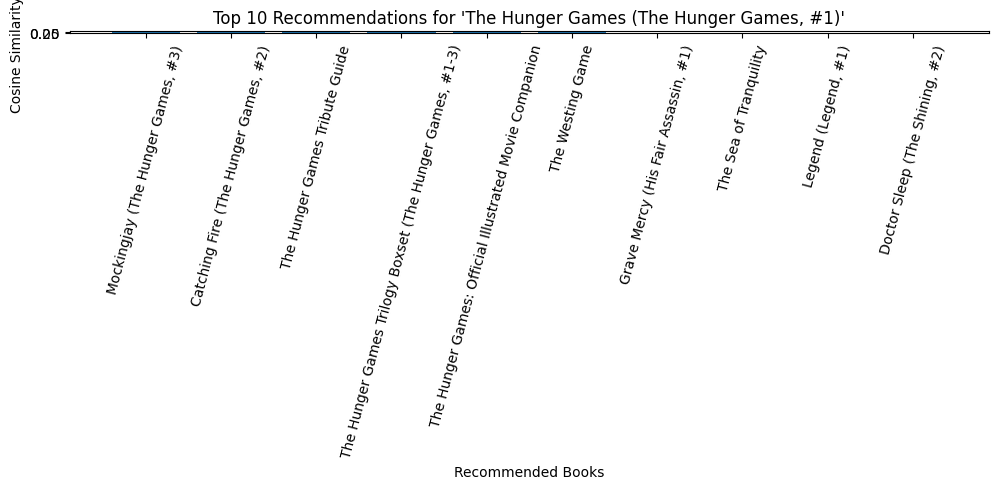

In [51]:
import matplotlib.pyplot as plt

sample_title = df["Title"].iloc[0]
result = recommend_books(sample_title, top_n=10)

plt.figure(figsize=(10, 5))
plt.bar(result["Title"], result["similarity_score"])
plt.xticks(rotation=75)
plt.title(f"Top 10 Recommendations for '{sample_title}'")
plt.xlabel("Recommended Books")
plt.ylabel("Cosine Similarity Score")
plt.tight_layout()
plt.show()